In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pyRRG.calc_shear import calc_shear
from RRGtools import run_match
from astropy.io import fits
from astropy import units
import numpy as np
from lenspack.utils import bin2d
from matplotlib import pyplot as plt
import pickle as pkl
from astropy.cosmology import Planck18
import lenspack
from scipy.ndimage import gaussian_filter
from scipy.stats import norm, chi
from get_model_probabilities import *

Source redshift:1.36


Galaxy density for concat is 321.0816326530612/arcmin2
Found 30 Models


100%|█████████████████████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 108.66it/s]


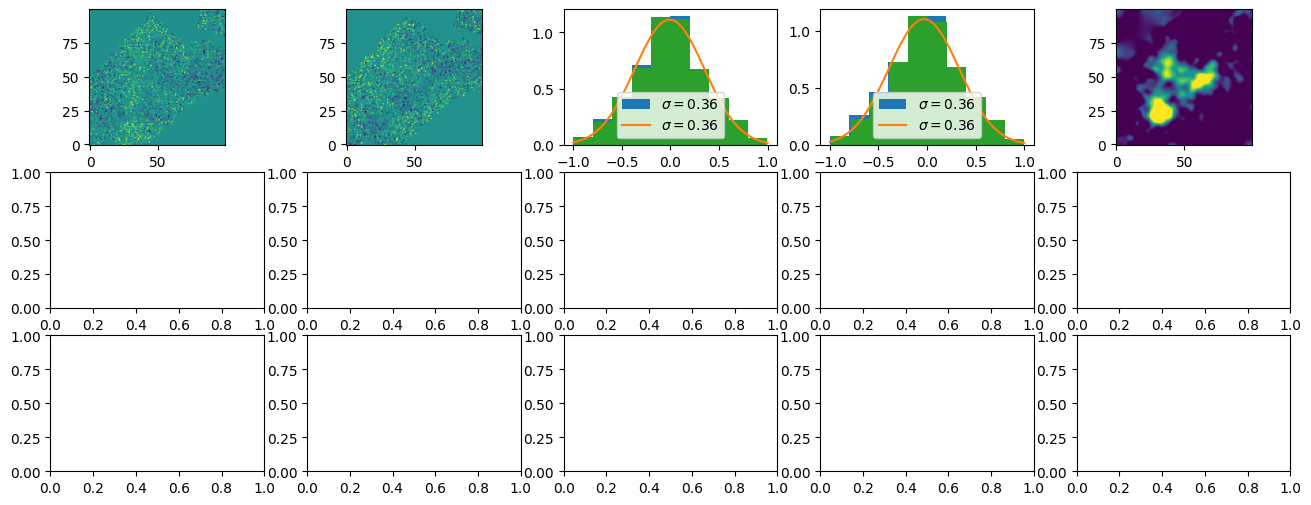

In [4]:

nmonte=2

filter_list = ['concat']

fig, ax = plt.subplots(3,5, figsize=(16,6))



for ifx, ifilter in enumerate(filter_list):
    obs_data = get_obs_data( ifilter, data_dir="../data/a2744/")
    
    g = np.sqrt( obs_data['gamma1']**2 + obs_data['gamma2']**2)
    
    ell = 2.*g/(1+g**2)
    
    obs_data['gamma1'] = 2.*obs_data['gamma1']/(1.+g**2)
    obs_data['gamma2'] = 2.*obs_data['gamma2']/(1.+g**2)
   
    if ifilter != 'concat':
        print(f"Min SNR {obs_data['snr'].min()}")
        print(f"Max MAG {obs_data['MAG_AUTO'].max()}")
        print(f"Max SIZE {obs_data['gal_size'].min()}")

    image_size = 100

    delta_ra, delta_dec = ra_dec_to_simulation_image_pos( obs_data )

    
    e1_radec, e2_radec = bin2d( 
                delta_ra, delta_dec, 
                v=(obs_data['gamma1'], obs_data['gamma2']),
                npix=image_size,
                extent=[
                    -image_size//2,image_size//2,-image_size//2,image_size//2
                ]
            )
    
    ngal = bin2d( 
                delta_ra, delta_dec, 
                v=None,
                npix=image_size,
                extent=[
                    -image_size//2,image_size//2,-image_size//2,image_size//2
                ]
            )
    egal = np.sqrt(
        obs_data['e1']**2 + obs_data['e2']**2
    )
    
    dict_dump = {
        'ngal':ngal, 'chi_fit_function':chi.fit(egal)
    }

    pkl.dump(dict_dump,open(f"pickles/ngal_{ifilter}.pkl","wb"))
    

  
    
    ax[ifx, 0].imshow(e1_radec, origin='lower')
    ax[ifx, 1].imshow(e2_radec, origin='lower')
    
    ax[ifx, 2].hist(obs_data['gamma1'],label=f"$\sigma={np.std(obs_data['gamma1']):0.2f}$", density=True)
    pdf = norm.fit(obs_data['gamma1'])
    x = np.linspace(-1,1,1000)
    ax[ifx, 2].plot(x, norm.pdf(x, *pdf), label=f"$\sigma={pdf[1]:0.2f}$")
   
    ax[ifx, 2].legend()
    ax[ifx, 3].hist(obs_data['gamma2'],label=f"$\sigma={np.std(obs_data['gamma2']):0.2f}$", density=True)
    pdf = norm.fit(obs_data['gamma2'])
    x = np.linspace(-1,1,1000)
    ax[ifx, 3].plot(x, norm.pdf(x, *pdf), label=f"$\sigma={pdf[1]:0.2f}$")
   
    ax[ifx, 3].legend()

    obs_data['x'] = delta_ra
    obs_data['y'] = delta_dec
    
    ke, kb = get_kappa( obs_data,  smooth=2, 
                       extent =[-image_size//2,image_size//2,-image_size//2,image_size//2])
    
    ax[ifx, 4].imshow(ke/np.std(kb), vmin=0, vmax=5., origin='lower')
    ax[ifx, 4].set_xlabel(f"Max SNR={np.max(ke/np.std(kb)):0.2f}")       

    
    theta = np.arctan2(
        obs_data['gamma2'], obs_data['gamma1']
    )/2. 

    max_val = np.max([
        e1_radec, e2_radec
    ])
    min_val = np.min([
        e1_radec, e2_radec
    ])

    e1_radec -= min_val 
    e1_radec /= max_val 

    e2_radec -= min_val 
    e2_radec /= max_val 
   
    e1_stacked = [ e1_radec ]
    e2_stacked = [ e2_radec ]
    
    for i in range(nmonte):

        this_theta = np.random.uniform( 0, np.pi, theta.shape[0])
        

        e1 = ell*np.cos(2.*this_theta)
        e2 = ell*np.sin(2.*this_theta)
        
        if i==0:
            ax[ifx,2].hist( e1, density=True )
            ax[ifx,3].hist( e2 , density=True)
        
        e1_rot, e2_rot = bin2d( 
                delta_ra, delta_dec, 
                v=(e1, e2),
                npix=image_size,
                extent=[
                    -image_size//2,image_size//2,-image_size//2,image_size//2
                ]
            )


        max_val = np.max([
            e1_rot, e2_rot
        ])
        min_val = np.min([
            e1_rot, e2_rot
        ])

        e1_rot -= min_val# ( e1_rot - min_val)/(max_val - min_val)
        e1_rot /= max_val#( e1_rot - min_val)/(max_val - min_val)

        e2_rot -= min_val#( e2_rot - min_val)/(max_val - min_val)
        e2_rot /= max_val#( e2_rot - min_val)/(max_val - min_val)


        e1_stacked.append( e1_rot )
        e2_stacked.append( e2_rot )
    e1_stacked = np.array(e1_stacked)
    e2_stacked = np.array(e2_stacked)

    stacked = np.append(e1_stacked[None,:,:,:], e2_stacked[None,:,:,:], axis=0)
    stacked = np.moveaxis( stacked, 0, 1)
    
    uncover_footprint = 49. #/ arcmin2
    galdensity = delta_ra.shape[0]/uncover_footprint
    print(f"Galaxy density for {ifilter} is {galdensity}/arcmin2")
    pkl.dump([{}, stacked],open(f"../data/a2744/obs_data_{ifilter}.pkl","wb"))
    
    
#RUN ALL MODELS ON THE TEST DATA
#-------------------------------
args.source_domain='a2744'
args.target_domain='a2744'

models = {}
probabilities = {}
probabilities_noise = {}

for ifx, ifilter in enumerate(filter_list):
    
    
    cdan_models = np.sort(glob(
        f"../models/{ifilter}/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth"
    ))
    all_models = []
    for imodel in cdan_models:
        args.checkpoint = imodel
        this_model = create_model(args)
        
        model_name = f"seed_{this_model.args.seed}"
        #if target_test_accuracy[ifilter][model_name]['target_test_f1'] <0.48:
        #    continue
            
        all_models.append(this_model)
    print(f"Found {len(all_models)} Models")
    models[ifilter] = all_models
    meta, data = pkl.load(open(f"../data/a2744/obs_data_{ifilter}.pkl","rb"))

    #repeat 
    probabilities_filt = []
    probabilities_noise_filt = []

    with torch.no_grad():

        for imodel in tqdm(all_models):
            outputs_dict = imodel([torch.tensor(data,dtype=torch.float32)])
            #if torch.all(torch.abs(outputs_dict['classification'][:,0] - outputs_dict['classification'][0,0])  < 0.01):
            #   continue
            probabilities_filt.append(torch.softmax( outputs_dict['classification'], dim=1 )[0,0]) 
            probabilities_noise_filt.append(torch.softmax( outputs_dict['classification'], dim=1 )[1:,0])
            

    probabilities_filt = torch.tensor( probabilities_filt).detach().numpy()
    probabilities_noise_filt =  torch.stack( probabilities_noise_filt).detach().numpy()

        
    probabilities[ifilter] = probabilities_filt
    probabilities_noise[ifilter] = probabilities_noise_filt
pkl.dump([{}, probabilities, probabilities_noise], open("pickles/model_on_data.pkl","wb"))